## Unsupervised Fraud & Anomaly Detection in Bank Transactions Project


### Part 1: EDA

EDA Findings:
- The histogram indicates that the distribution of transaction amounts is highly right-skewed, meaning that most transactions are small, while a few transactions have large values. The box plot reinforces this observation, showing that the majority of transactions fall between approximately $200-$400. However, several extreme outliers are present, with transaction amounts spanning from approximately $800-$2000. These large transactions may indicate unsual behavior and should be further investigated for fraud.

- Transaction dates exhibit a relatively uniform distribution, with a smooth density curve, indicating that they follow a consistent pattern. This implies that overall transaction activity remains stable throughout the year.

- The majority of transactions are conducted through debit, with a fairly even distribution across channels: Online, ATM, and Branch.

-  The distribution of customer ages shows a slight bimodal pattern, with significant concentrations in the age groups of 18-30 years (younger adults) and 50-60 years (middle-aged adults). There are fewer customers in the 35-45 age range and among those older than 70. This suggests that the majority of transactions are carried out by younger and middle-aged adults.

- The distribution of account balances shows a bimodal pattern. Most accounts have low balances ($0 - $2000), while a smaller group has high balances ($6000 - $8000). This trend suggests the existence of different customer groups, such as new customers and long-term customers.

- The heatmap shows a weak relationship between most of the features before feature engineering.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv("bank_transactions_data.csv")

# View the first few records of the dataframe
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


###### 1. Overview of dataset structure (columns, types, missing values, duplicates)


In [3]:
# Inspect column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [4]:
# Check for null values
df.isna().sum()

TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [5]:
# Check for duplicates
df.duplicated().sum()

0

In [6]:
# Parse timestamps for the TransactionDate and PreviousTransactionDate columns
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


###### 2. Descriptive statistics for key numeric variables

In [7]:
# View summary statistics
df.describe()

,TransactionAmount,TransactionDate,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2512.000000,2512,2512.000000,2512.000000,2512.000000,2512.000000,2512
mean,297.593778,2023-07-05 20:32:10.826433024,44.673965,119.643312,1.124602,5114.302966,2024-11-04 08:09:22.219745024
min,0.260000,2023-01-02 16:00:06,18.000000,10.000000,1.000000,101.250000,2024-11-04 08:06:23
25%,81.885000,2023-04-03 16:22:05.750000128,27.000000,63.000000,1.000000,1504.370000,2024-11-04 08:07:53
50%,211.140000,2023-07-07 17:49:43.500000,45.000000,112.500000,1.000000,4735.510000,2024-11-04 08:09:22
75%,414.527500,2023-10-06 18:40:53.500000,59.000000,161.000000,1.000000,7678.820000,2024-11-04 08:10:53.249999872
max,1919.110000,2024-01-01 18:21:50,80.000000,300.000000,5.000000,14977.990000,2024-11-04 08:12:23
std,291.946243,NaN,17.792198,69.963757,0.602662,3900.942499,NaN


###### 3. Data Quality Checks

In [8]:
# Check for uniqueness in Transaction IDs
df['TransactionID'].is_unique

True

In [9]:
# Check for the reasonableness of numeric ranges (e.g., amounts of non-negative)
(df['TransactionAmount'] > 0).sum()

2512

###### 4. Distribution visualizations

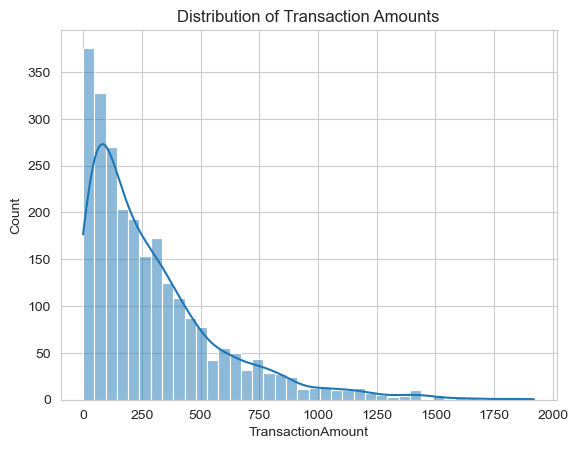

In [10]:
sns.set_style('whitegrid')

# Visualize the distribution of transaction amounts
sns.histplot(df['TransactionAmount'], kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

Text(0.5, 1.0, 'Distribution of Transaction Amounts')

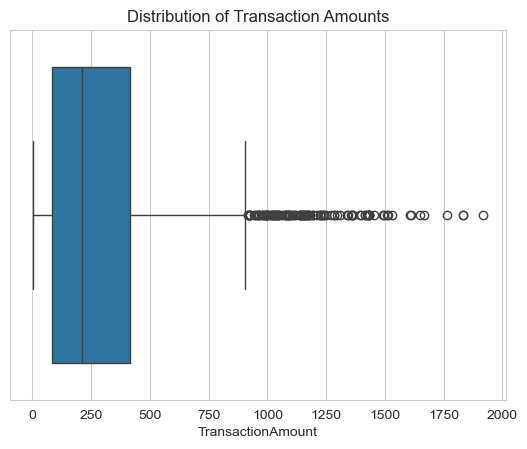

In [11]:
sns.boxplot(x=df['TransactionAmount'])
plt.title('Distribution of Transaction Amounts')

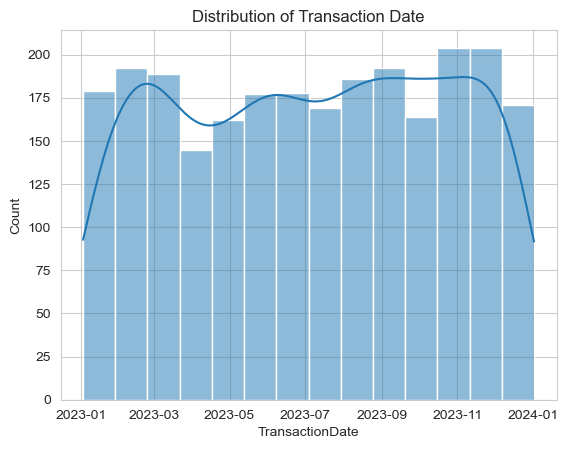

In [12]:
# Visualize the distribution of transaction dates
sns.histplot(df['TransactionDate'], kde=True)
plt.title('Distribution of Transaction Date')
plt.show()

Text(0.5, 1.0, 'Distribution of Transaction Dates')

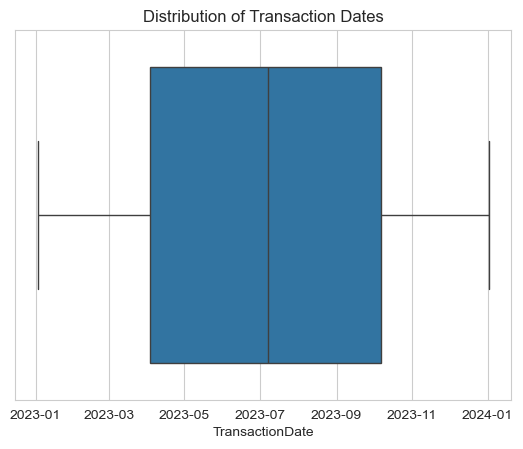

In [13]:
sns.boxplot(x=df['TransactionDate'])
plt.title('Distribution of Transaction Dates')

In [14]:
# Inspect the categorical value sets in the TransactionType column
df['TransactionType'].value_counts()

TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64

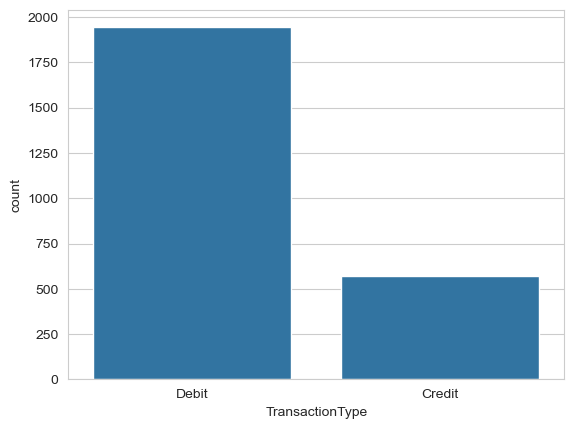

In [15]:
# Visualize the distribution of transaction types
sns.countplot(data=df, x='TransactionType')
plt.show()

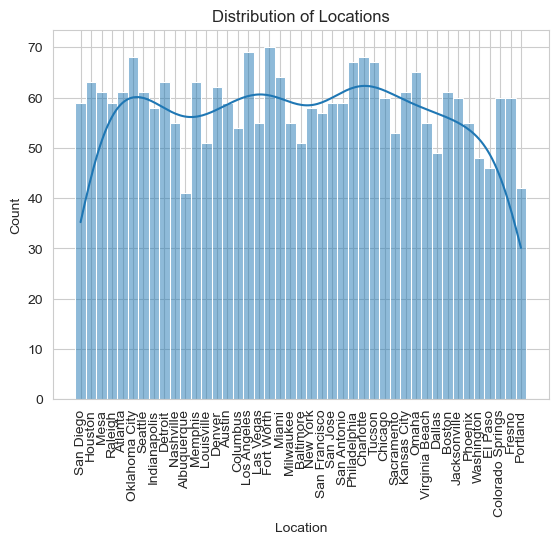

In [16]:
# Visualize the distribution of locations
sns.histplot(df['Location'], kde=True)
plt.title('Distribution of Locations')
plt.xticks(rotation=90)
plt.show()

In [17]:
# Inspect the categorical value sets in the Channel column
df['Channel'].value_counts()

Channel
Branch    868
ATM       833
Online    811
Name: count, dtype: int64

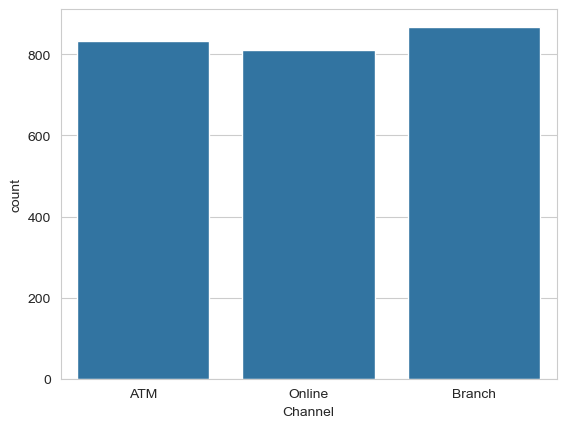

In [18]:
# Visualize the distribution of channels
sns.countplot(data=df, x='Channel')
plt.show()

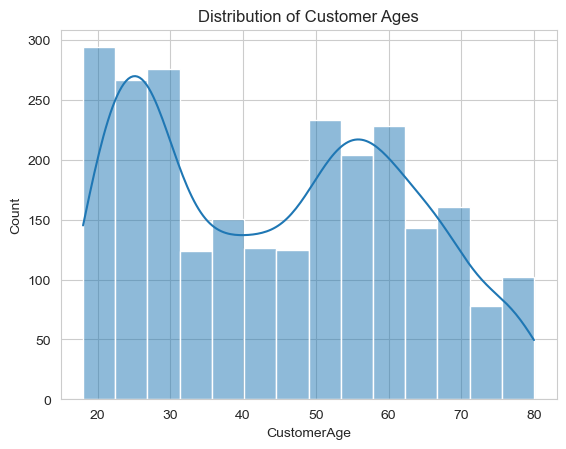

In [19]:
# Visualize the distribution of customer's ages
sns.histplot(df['CustomerAge'], kde=True)
plt.title('Distribution of Customer Ages')
plt.show()

Text(0.5, 1.0, 'Distribution of Customer Ages')

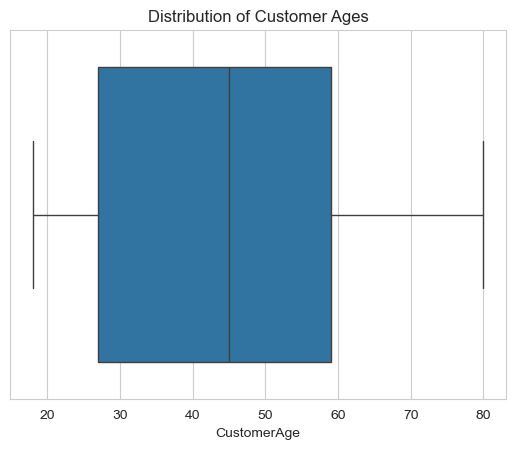

In [20]:
sns.boxplot(x=df['CustomerAge'])
plt.title('Distribution of Customer Ages')

<Axes: xlabel='CustomerOccupation', ylabel='count'>

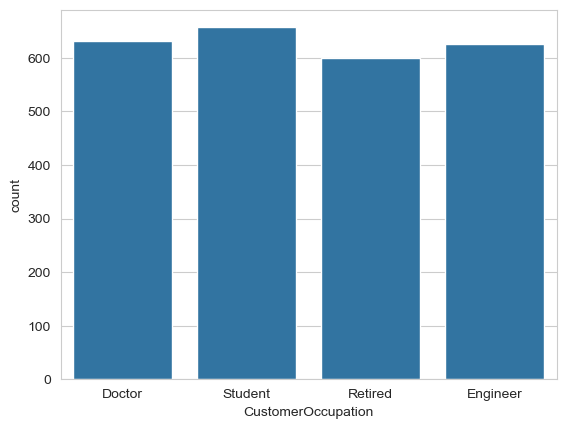

In [21]:
# Visualize the distribution of customer's occupations
sns.countplot(data=df, x='CustomerOccupation')

Text(0.5, 1.0, 'Distribution of Transaction Duration')

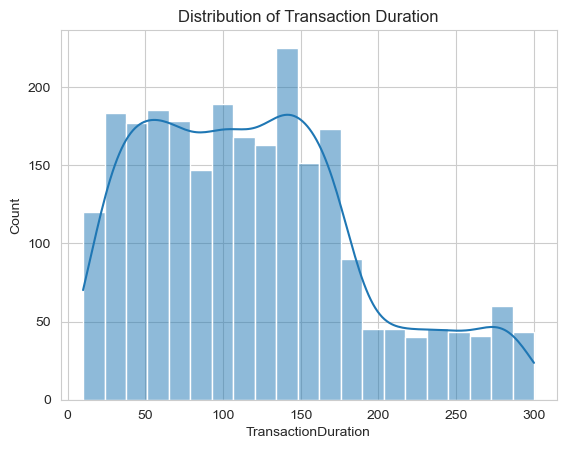

In [22]:
# Visualize the distribution of transaction duration
sns.histplot(df['TransactionDuration'], kde=True)
plt.title('Distribution of Transaction Duration')

Text(0.5, 1.0, 'Distribution of Transaction Duration')

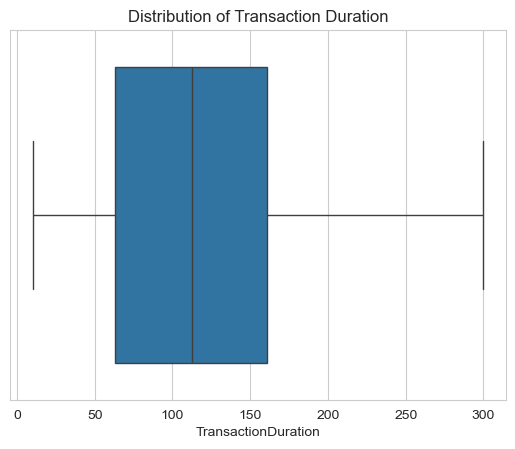

In [23]:
sns.boxplot(x=df['TransactionDuration'])
plt.title('Distribution of Transaction Duration')

<Axes: xlabel='LoginAttempts', ylabel='count'>

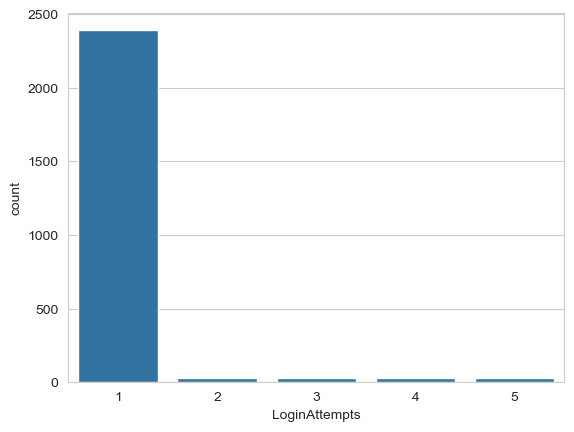

In [24]:
# Visualize the distribution of login attempts
sns.countplot(x=df['LoginAttempts'])

Text(0.5, 1.0, 'Distribution of Account Balance')

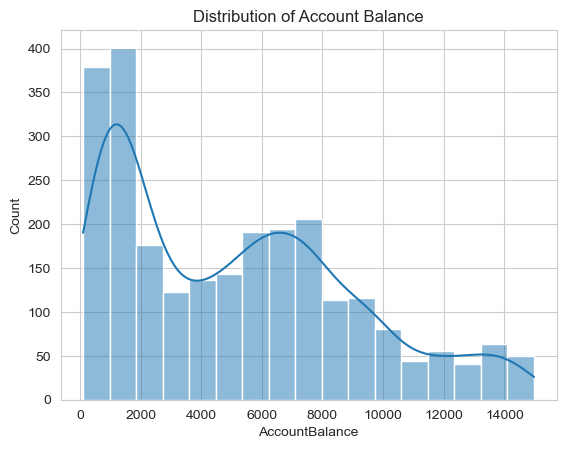

In [25]:
# Visualize the distribution of account balances
sns.histplot(df['AccountBalance'], kde=True)
plt.title('Distribution of Account Balance')

Text(0.5, 1.0, 'Distribution of Account Balance')

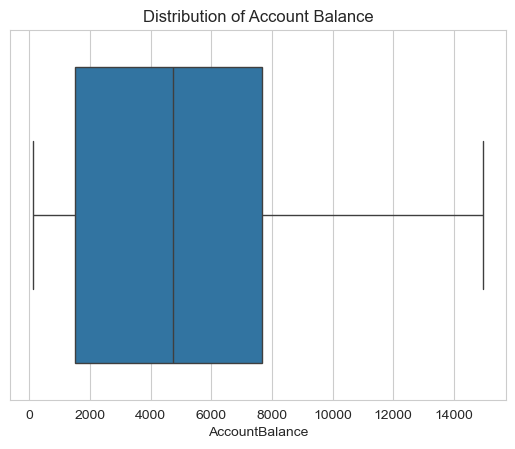

In [26]:
sns.boxplot(data=df, x='AccountBalance')
plt.title('Distribution of Account Balance')

In [27]:
# Compute the number of transactions per account
tx_per_acct = df.groupby('AccountID').size().sort_values(ascending=False)

# Identify the top 10 accounts with the highest volume of transactions
tx_per_acct.head(10)

AccountID
AC00202    12
AC00460    12
AC00363    12
AC00362    12
AC00456    11
AC00480    11
AC00257    11
AC00304    11
AC00225    11
AC00063    10
dtype: int64

Text(0.5, 1.0, 'Transactions per Account')

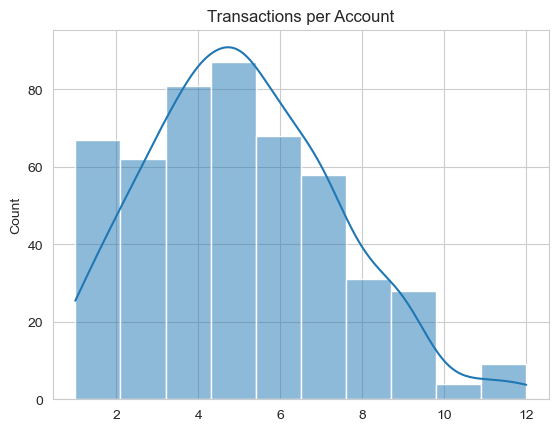

In [28]:
# Visualize the distribution of transactions per account
sns.histplot(tx_per_acct, bins=10, kde=True); # Long tail skewed to the right

plt.title('Transactions per Account')

Text(0.5, 1.0, 'Accounts per City')

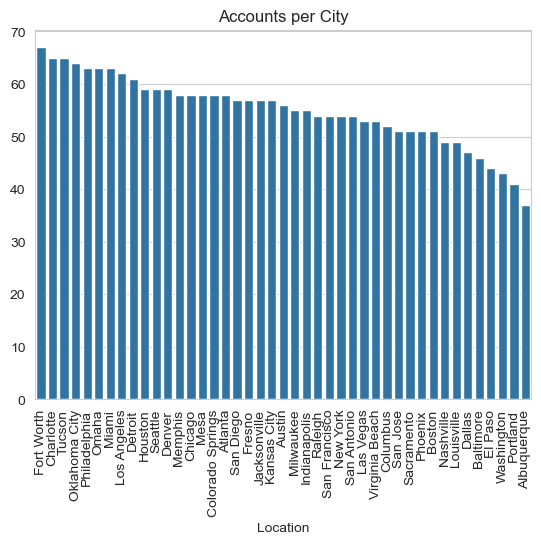

In [29]:
# Count distinct accounts per city
accounts_per_city = df.groupby('Location')['AccountID'].nunique().sort_values(ascending=False)

# Count total transactions per city
tx_per_city = df.groupby('Location').size().sort_values(ascending=False)

# Visualize the amount of distinct accounts per city
sns.barplot(x=accounts_per_city.index, y=accounts_per_city.values)
plt.xticks(rotation=90);
plt.title('Accounts per City')

In [30]:
# Identify the top merchants by count and amount
top_merchants = df.groupby('MerchantID')['TransactionAmount'].agg(['count', 'sum']).sort_values('count', ascending=False)

# Identify the top 10 merchants by count and amount
top_merchants.head(10)

,count,sum
MerchantID,,
M026,45,13865.15
M066,34,11948.75
M028,33,10316.32
M014,33,9468.00
M013,33,10416.35
M065,33,7936.56
M015,32,9536.75
M001,32,8320.08
M068,32,9680.07


In [31]:
# Compute merchant diversity per account
merch_diversity = df.groupby('AccountID')['MerchantID'].nunique().sort_values(ascending=False)
merch_diversity

AccountID
AC00202    12
AC00363    12
AC00225    11
AC00456    11
AC00257    11
           ..
AC00440     1
AC00469     1
AC00472     1
AC00473     1
AC00406     1
Name: MerchantID, Length: 495, dtype: int64

Text(0.5, 1.0, 'Merchant Diversity per Account')

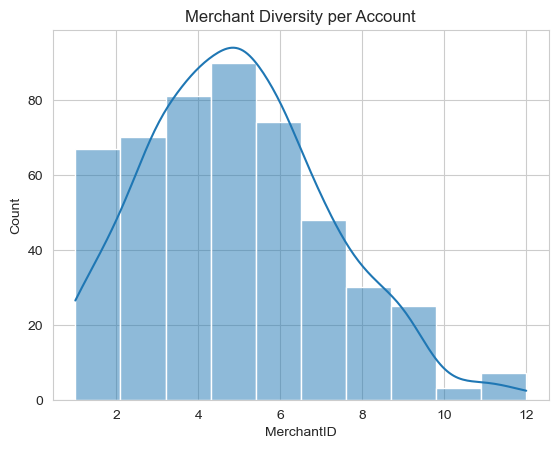

In [32]:
# Visualize the distribution of unique merchants per account
sns.histplot(merch_diversity, bins=10, kde=True);
plt.title('Merchant Diversity per Account')

###### 5. Relationships between important features

<Axes: >

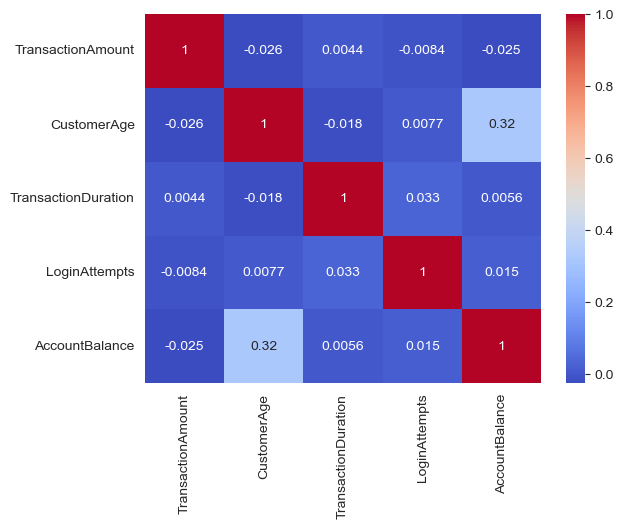

In [33]:
# Visualize feature correlations using a heatmap
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

### Part 2 - Feature Engineering

Engineered Features

- TimeSincePreviousTransaction: This feature measures the duration between two transactions. Short intervals between transactions may suggest possible fraudulent activity.


- TransactionHour: This feature extracts the hour of the transaction from the transaction date. It can be used to analyze temporal patterns.

- TransactionDay: This feature extracts the day of the transaction from the transaction date. It can help analyze patterns based on specific days.

- TransactionMonth: This feature extracts the month of the transaction from the transaction date. It can be useful for analyzing seasonal trends.

- AmountZScore: This feature calculates the z-score of transaction amounts for each account. Extreme outliers may indicate potential fraud

- TransactionPerHour: This feature calculates the number of transactions made per hour for each account. A high frequency of transactions within a short time frame may suggest possible fraudulent behavior.

In [34]:
# Create a new column in the df that extracts the values of the time between transactions
df['TimeSincePreviousTransaction'] = (df['PreviousTransactionDate'] - df['TransactionDate']).dt.total_seconds()
df['TimeSincePreviousTransaction']

0       49477134.0
1       42823516.0
2       41694656.0
3       47403415.0
4       33228915.0
           ...    
2507    48178913.0
2508    51201294.0
2509    38069989.0
2510    53452056.0
2511    54315986.0
Name: TimeSincePreviousTransaction, Length: 2512, dtype: float64

Text(0.5, 1.0, 'Distribution of Time Since Previous Transaction')

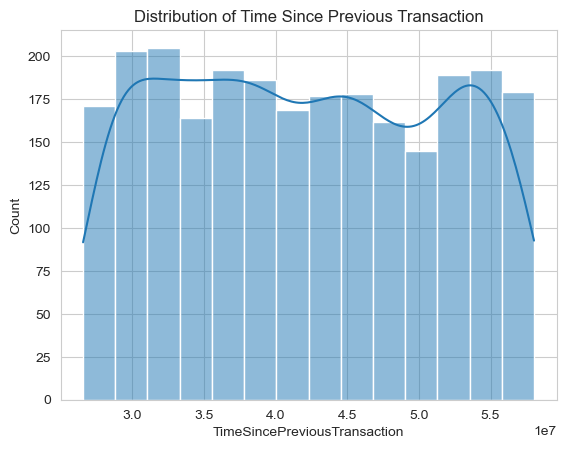

In [35]:
# Visualize the distribution of the time since previous transactions
sns.histplot(df['TimeSincePreviousTransaction'], kde=True)
plt.title('Distribution of Time Since Previous Transaction')

In [36]:
# Create a new column in the df that extracts the transaction hour
df['TransactionHour'] = df['TransactionDate'].dt.hour

# Create a new column in the df that extracts the transaction day
df['TransactionDay'] = df['TransactionDate'].dt.day

# Create a new column in the df that extracts the transaction month
df['TransactionMonth'] = df['TransactionDate'].dt.month

In [37]:
# Calculate the total transaction amount per account
amount_per_acct = df.groupby('AccountID').agg({'TransactionAmount': 'sum'}).sort_values('TransactionAmount', ascending=False)
amount_per_acct

,TransactionAmount
AccountID,
AC00460,5570.34
AC00363,4702.91
AC00337,4393.41
AC00021,4263.34
AC00439,4185.81
...,...
AC00117,55.32
AC00309,52.04
AC00134,49.59


In [38]:
# Calculate the amount z-scores by account
from scipy.stats import zscore

amount_per_acct['amount_zscore'] = zscore(amount_per_acct['TransactionAmount'])
amount_per_acct

,TransactionAmount,amount_zscore
AccountID,,
AC00460,5570.34,4.284829
AC00363,4702.91,3.369393
AC00337,4393.41,3.042764
AC00021,4263.34,2.905495
AC00439,4185.81,2.823674
...,...,...
AC00117,55.32,-1.535413
AC00309,52.04,-1.538874
AC00134,49.59,-1.541460


In [39]:
# Check for outliers
amount_per_acct[(amount_per_acct['amount_zscore'] > 3) | (amount_per_acct['amount_zscore'] < -3)]

,TransactionAmount,amount_zscore
AccountID,,
AC00460,5570.34,4.284829
AC00363,4702.91,3.369393
AC00337,4393.41,3.042764


In [40]:
# Map the amount zscores per account to the account id in the dataframe
df['AmountZScore'] = df['AccountID'].map(amount_per_acct['amount_zscore'])
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,Doctor,81,1,5112.21,2024-11-04 08:08:08,49477134.0,16,11,4,1.809573
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,Doctor,141,1,13758.91,2024-11-04 08:09:35,42823516.0,16,27,6,0.656579
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,Student,56,1,1122.35,2024-11-04 08:07:04,41694656.0,18,10,7,-0.593128
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,Student,25,1,8569.06,2024-11-04 08:09:06,47403415.0,16,5,5,0.402779
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,Student,198,1,7429.40,2024-11-04 08:06:39,33228915.0,17,16,10,0.184228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,...,Doctor,109,1,12690.79,2024-11-04 08:11:29,48178913.0,17,26,4,1.291231
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,...,Doctor,177,1,254.75,2024-11-04 08:11:42,51201294.0,17,22,3,1.642597
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,...,Retired,146,1,3382.91,2024-11-04 08:08:39,38069989.0,17,21,8,1.764173
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,...,Student,19,1,1776.91,2024-11-04 08:12:22,53452056.0,16,24,2,-0.273981


In [41]:
# Calculate the total amount of transactions per hour for each account
transactions_per_hour = df.groupby(['AccountID', 'TransactionHour'])['TransactionHour'].transform('count')
transactions_per_hour

# Add to the df
df['TransactionsPerHour'] = transactions_per_hour
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,81,1,5112.21,2024-11-04 08:08:08,49477134.0,16,11,4,1.809573,4
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,141,1,13758.91,2024-11-04 08:09:35,42823516.0,16,27,6,0.656579,4
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,56,1,1122.35,2024-11-04 08:07:04,41694656.0,18,10,7,-0.593128,1
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,25,1,8569.06,2024-11-04 08:09:06,47403415.0,16,5,5,0.402779,4
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,198,1,7429.40,2024-11-04 08:06:39,33228915.0,17,16,10,0.184228,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,...,109,1,12690.79,2024-11-04 08:11:29,48178913.0,17,26,4,1.291231,4
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,...,177,1,254.75,2024-11-04 08:11:42,51201294.0,17,22,3,1.642597,3
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,...,146,1,3382.91,2024-11-04 08:08:39,38069989.0,17,21,8,1.764173,3
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,...,19,1,1776.91,2024-11-04 08:12:22,53452056.0,16,24,2,-0.273981,4


### 3. Dimensionality Reduction

Using TSNE, the visualization reveals that:
- The data contains multiple distinct clusters, implying that groups of transactions share similar behavioral patterns. These clusters likely correspond to different customer segments or behaviors.

-  After feature engineering, greater segmentation is observed, suggesting that the engineered features (transaction frequency, temporal features, and z-scores) have improved the model's ability to differentiate between behavioral patterns.

- A small, dense, isolated cluster appears at around Dim_1 = -20. This cluster warrants further investigation for potential fraud, automated activity, or unusual behavior.

- Some clusters are more loosely distributed, reflecting a wider variation in transaction behavior within these groups. These clusters likely represent accounts with diverse spending patterns.

- A few observations are located outside the main clusters or on the outskirts of loose clusters. These points may represent anomalies and should be investigated further.

In [42]:
# Select the low-cardinality features
low_cardinality = ['TransactionType', 'Channel', 'CustomerOccupation']

# Select the high-cardinality features
high_cardinality = ['TransactionID', 'AccountID', 'Location', 'DeviceID', 'IP Address', 'MerchantID']

# Encode low-cardinality features using one-hot encoding
one_hot = pd.get_dummies(df[low_cardinality], drop_first=True)

# Encode high-cardinality features using frequency encoding
frequency = df[high_cardinality].apply(lambda x: x.map(x.value_counts()))
frequency

# Concat the encoded data with the numeric data
data = pd.concat([df.select_dtypes(include='number'), frequency, one_hot], axis=1)
data

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,...,Location,DeviceID,IP Address,MerchantID,TransactionType_Debit,Channel_Branch,Channel_Online,CustomerOccupation_Engineer,CustomerOccupation_Retired,CustomerOccupation_Student
0,14.09,70,81,1,5112.21,49477134.0,16,11,4,1.809573,...,59,6,3,32,True,False,False,False,False,False
1,376.24,68,141,1,13758.91,42823516.0,16,27,6,0.656579,...,63,5,4,27,True,False,False,False,False,False
2,126.29,19,56,1,1122.35,41694656.0,18,10,7,-0.593128,...,61,5,7,30,True,False,True,False,False,True
3,184.50,26,25,1,8569.06,47403415.0,16,5,5,0.402779,...,59,6,8,31,True,False,True,False,False,True
4,13.45,26,198,1,7429.40,33228915.0,17,16,10,0.184228,...,61,3,4,31,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,856.21,33,109,1,12690.79,48178913.0,17,26,4,1.291231,...,60,3,1,15,False,True,False,False,False,False
2508,251.54,48,177,1,254.75,51201294.0,17,22,3,1.642597,...,67,5,5,25,True,True,False,False,False,False
2509,28.63,56,146,1,3382.91,38069989.0,17,21,8,1.764173,...,59,5,4,25,True,True,False,False,True,False
2510,185.97,23,19,1,1776.91,53452056.0,16,24,2,-0.273981,...,62,2,6,20,True,False,True,False,False,True


In [43]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(data)

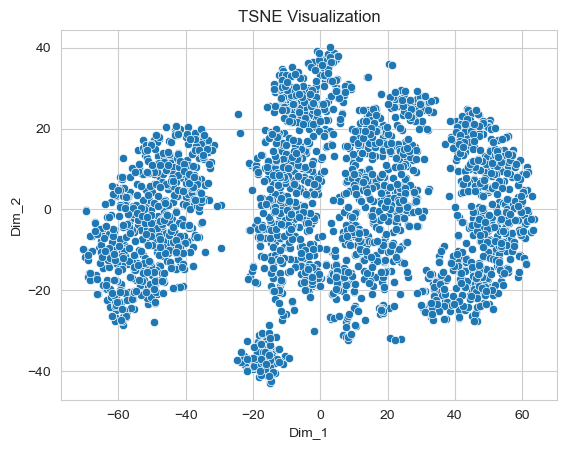

In [44]:
from sklearn.manifold import TSNE

# Create a TSNE model
tsne = TSNE(n_components=2, random_state=0).fit_transform(scaled)

# Convert TSNE data into a df
tsne_df = pd.DataFrame(tsne, columns=['Dim_1', 'Dim_2'])

# Visualize the dimensions
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2')
plt.title('TSNE Visualization')
plt.show()

### 4. Unsupervised Anomaly Detection

Anomaly Detection:

- The top three anomalies identified using the Isolation Forest model were associated with transaction IDs: TX001162, TX000395, and TX000275. In contrast, the top anomalies detected by the Local Outlier Factor model were from the transaction IDs: TX001885, TX000147, and TX001492.

- The transactions flagged as anomalies by both models included: TX000275, TX000147, and TX001492.

- Most of the potentially fraudulent transactions detected using the Isolation Forest model exhibited high transaction amounts.

- The majority of the anomalies identified by both methods belonged to a small, dense, isolated cluster as shown in the TSNE visualization.

- A smaller number of transactions were detected by the Local Outlier Factor model compared to the Isolation Forest model, with 6 and 26 anomalies, respectively.

- The suspicious transactions identified using the Isolation Forest model demonstrated a weak-to-moderate correlation (0.46) between Transaction Amount and Amount Z-Score. A scatterplot visualization indicated that many anomalies had both high transaction amounts and high z-scores for each account.

- Additionally, the suspicious transactions detected with the Isolation Forest model showed a weak-to-moderate correlation (0.36) between Account Balance and Transaction Duration. A scatterplot visualization revealed that many anomalies had longer transaction durations.


In [45]:
# Isolation Forest
from sklearn.ensemble import IsolationForest

# Train model
iso = IsolationForest(n_estimators=100, contamination=0.01, random_state=0)
iso.fit(scaled)

IsolationForest(contamination=0.01, random_state=0)

In [46]:
# Optimize the Isolation Forest Parameters
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param = {
    'n_estimators': [100, 200],
    'max_samples': ['auto', 0.5],
    'contamination': [0.01, 0.1, 0.02, 0.05]
}

# Define the scoring function
def iso_scores(estimator, X):
  scores = estimator.decision_function(X)
  return np.mean(scores)

iso2 = IsolationForest(random_state=0)

grid_search = GridSearchCV(estimator=iso2, param_grid=param, cv=3, scoring=iso_scores)
grid_search.fit(scaled)

GridSearchCV(cv=3, estimator=IsolationForest(random_state=0),
             param_grid={'contamination': [0.01, 0.1, 0.02, 0.05],
                         'max_samples': ['auto', 0.5],
                         'n_estimators': [100, 200]},
             scoring=<function iso_scores at 0x30f435e40>)

In [47]:
# Print the best parameters
print(grid_search.best_params_)

optimized_iso = grid_search.best_estimator_

{'contamination': 0.01, 'max_samples': 0.5, 'n_estimators': 100}


In [48]:
# Predict anomalies
df['IFAnomaly'] = optimized_iso.predict(scaled)
df['IFAnomaly_Score'] = optimized_iso.decision_function(scaled)

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,AccountBalance,PreviousTransactionDate,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour,IFAnomaly,IFAnomaly_Score
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,5112.21,2024-11-04 08:08:08,49477134.0,16,11,4,1.809573,4,1,0.123230
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,13758.91,2024-11-04 08:09:35,42823516.0,16,27,6,0.656579,4,1,0.123331
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,1122.35,2024-11-04 08:07:04,41694656.0,18,10,7,-0.593128,1,1,0.102323
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,8569.06,2024-11-04 08:09:06,47403415.0,16,5,5,0.402779,4,1,0.094116
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,7429.40,2024-11-04 08:06:39,33228915.0,17,16,10,0.184228,1,1,0.073100


In [49]:
# Select all the isolation forest anomalies
if_anomalies = df[df['IFAnomaly'] == -1]

# Sort the anomalies by their anomaly score
if_anomalies = if_anomalies.sort_values('IFAnomaly_Score')

# View the top isolation forest anomalies
if_anomalies.head(10)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,AccountBalance,PreviousTransactionDate,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour,IFAnomaly,IFAnomaly_Score
1161,TX001162,AC00460,484.30,2023-10-17 17:46:52,Credit,Boston,D000407,93.160.83.196,M026,Online,...,7910.30,2024-11-04 08:11:08,33143056.0,17,17,10,4.284829,4,-1,-0.038241
394,TX000395,AC00326,6.30,2023-12-14 18:52:54,Debit,Columbus,D000539,210.160.90.52,M017,Branch,...,7697.68,2024-11-04 08:12:13,28127959.0,18,14,12,-0.336838,1,-1,-0.033275
274,TX000275,AC00454,1176.28,2023-12-20 16:08:02,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,...,323.69,2024-11-04 08:11:44,27619422.0,16,20,12,0.492336,1,-1,-0.029078
898,TX000899,AC00083,1531.31,2023-10-23 18:00:29,Debit,San Diego,D000319,91.204.200.167,M078,Online,...,859.86,2024-11-04 08:06:40,32623571.0,18,23,10,1.311968,1,-1,-0.020402
176,TX000177,AC00363,1362.55,2023-02-10 18:07:07,Debit,El Paso,D000213,93.52.44.101,M001,ATM,...,2429.68,2024-11-04 08:11:05,54655438.0,18,10,2,3.369393,2,-1,-0.020212
614,TX000615,AC00466,1342.25,2023-04-28 18:11:55,Credit,Fort Worth,D000643,28.149.72.129,M032,Branch,...,694.03,2024-11-04 08:08:00,48002165.0,18,28,4,1.188060,1,-1,-0.020142
1491,TX001492,AC00375,506.26,2023-12-18 18:26:07,Credit,Baltimore,D000670,200.136.146.93,M014,ATM,...,6266.65,2024-11-04 08:11:53,27783946.0,18,18,12,-0.560338,1,-1,-0.019461
1703,TX001704,AC00205,1294.81,2023-12-11 16:53:08,Credit,Washington,D000489,76.0.164.168,M026,Branch,...,9927.75,2024-11-04 08:11:44,28394316.0,16,11,12,0.155976,4,-1,-0.018617
1213,TX001214,AC00170,1192.20,2023-12-21 16:21:27,Credit,Jacksonville,D000174,40.10.25.102,M093,Branch,...,7816.41,2024-11-04 08:09:14,27532067.0,16,21,12,0.233301,6,-1,-0.018044
2124,TX002125,AC00039,737.46,2023-01-03 16:28:03,Credit,Albuquerque,D000443,202.194.199.70,M037,Branch,...,634.16,2024-11-04 08:07:37,57944374.0,16,3,1,0.644337,5,-1,-0.015686


In [50]:
# Check for suspicious IP Addresses for potential fraud rings
if_anomalies.groupby('IP Address').size().sort_values(ascending=False).head(10)

IP Address
200.136.146.93    2
202.194.199.70    2
87.50.72.69       2
101.223.82.253    1
42.219.228.159    1
93.160.83.196     1
92.180.81.50      1
91.204.200.167    1
88.55.149.101     1
76.0.164.168      1
dtype: int64

In [51]:
# Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor

# Train model
lof = LocalOutlierFactor(n_neighbors=5, contamination=0.01, novelty=True)
lof.fit(scaled)

LocalOutlierFactor(contamination=0.01, n_neighbors=5, novelty=True)

In [52]:
# Optimize the LOF Parameters

# Define the parameter grid
param = {
    'n_neighbors': [5, 10, 20],
    'contamination': [0.01, 0.02, 0.05],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Define the scoring function
def lof_scores(estimator, X):
  scores = estimator.score_samples(X)
  return np.mean(scores)

lof2 = LocalOutlierFactor(novelty=True)

grid_search2 = GridSearchCV(estimator=lof2, param_grid=param, cv=3, scoring=iso_scores)
grid_search2.fit(scaled)

GridSearchCV(cv=3, estimator=LocalOutlierFactor(novelty=True),
             param_grid={'contamination': [0.01, 0.02, 0.05],
                         'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [5, 10, 20]},
             scoring=<function iso_scores at 0x30f435e40>)

In [53]:
# Print the best parameters
print(grid_search.best_params_)

optimized_lof = grid_search2.best_estimator_

{'contamination': 0.01, 'max_samples': 0.5, 'n_estimators': 100}


In [54]:
# Predict anomalies
df['LOFAnomaly'] = optimized_lof.predict(scaled)
df['LOFAnomaly_Score'] = optimized_lof.score_samples(scaled)

df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour,IFAnomaly,IFAnomaly_Score,LOFAnomaly,LOFAnomaly_Score
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,...,49477134.0,16,11,4,1.809573,4,1,0.123230,1,-1.030408
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,...,42823516.0,16,27,6,0.656579,4,1,0.123331,1,-1.034870
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,...,41694656.0,18,10,7,-0.593128,1,1,0.102323,1,-0.946245
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,...,47403415.0,16,5,5,0.402779,4,1,0.094116,1,-1.097451
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,...,33228915.0,17,16,10,0.184228,1,1,0.073100,1,-0.978005


In [55]:
# Select all the LOF anomalies
lof_anomalies = df[df['LOFAnomaly'] == -1]

# Sort the anomalies by their anomaly score
lof_anomalies = lof_anomalies.sort_values('LOFAnomaly_Score')

# View the top LOF anomalies
lof_anomalies

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour,IFAnomaly,IFAnomaly_Score,LOFAnomaly,LOFAnomaly_Score
1884,TX001885,AC00071,451.31,2023-12-04 16:57:39,Debit,Fort Worth,D000020,68.254.244.208,M046,ATM,...,28998599.0,16,4,12,2.680475,3,1,0.002382,-1,-1.613017
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,...,37291704.0,17,30,8,2.776595,2,-1,-0.011191,-1,-1.541021
1491,TX001492,AC00375,506.26,2023-12-18 18:26:07,Credit,Baltimore,D000670,200.136.146.93,M014,ATM,...,27783946.0,18,18,12,-0.560338,1,-1,-0.019461,-1,-1.453969
1057,TX001058,AC00191,83.07,2023-01-06 16:13:53,Debit,Miami,D000182,138.210.196.19,M026,Branch,...,57686209.0,16,6,1,-1.054197,2,1,0.003414,-1,-1.451042
274,TX000275,AC00454,1176.28,2023-12-20 16:08:02,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,...,27619422.0,16,20,12,0.492336,1,-1,-0.029078,-1,-1.443355
1063,TX001064,AC00025,65.26,2023-12-08 17:05:35,Debit,Sacramento,D000489,77.208.193.198,M026,Branch,...,28652719.0,17,8,12,-1.155436,2,1,0.034944,-1,-1.439139


In [56]:
# Check if the isolation forest and lof anomalies share any transactions
if_anomalies[if_anomalies['TransactionID'].isin(lof_anomalies['TransactionID'])]

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,...,AccountBalance,PreviousTransactionDate,TimeSincePreviousTransaction,TransactionHour,TransactionDay,TransactionMonth,AmountZScore,TransactionsPerHour,IFAnomaly,IFAnomaly_Score
274,TX000275,AC00454,1176.28,2023-12-20 16:08:02,Credit,Kansas City,D000476,50.202.8.53,M074,ATM,...,323.69,2024-11-04 08:11:44,27619422.0,16,20,12,0.492336,1,-1,-0.029078
1491,TX001492,AC00375,506.26,2023-12-18 18:26:07,Credit,Baltimore,D000670,200.136.146.93,M014,ATM,...,6266.65,2024-11-04 08:11:53,27783946.0,18,18,12,-0.560338,1,-1,-0.019461
146,TX000147,AC00385,973.39,2023-08-30 17:23:20,Debit,Sacramento,D000292,202.194.199.70,M026,Branch,...,2042.22,2024-11-04 08:11:44,37291704.0,17,30,8,2.776595,2,-1,-0.011191


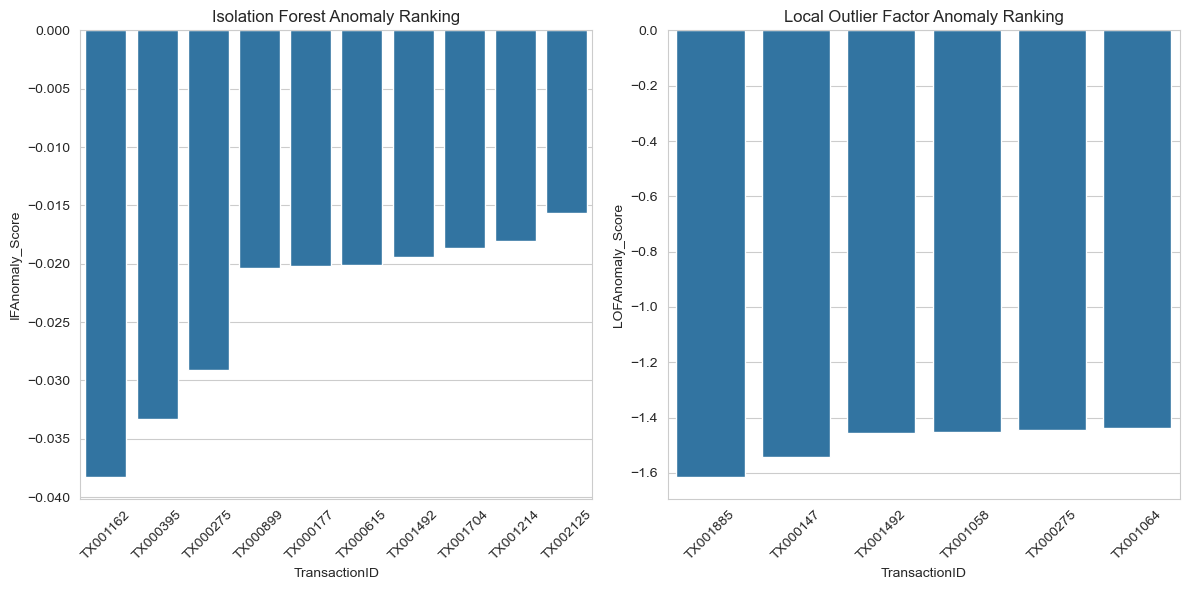

In [57]:
# Visualize the ranking of top anomalies
if_top = if_anomalies.head(10)
lof_top = lof_anomalies.head(10)

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.barplot(x=if_top['TransactionID'], y=if_top['IFAnomaly_Score'])
plt.title('Isolation Forest Anomaly Ranking')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.barplot(x=lof_top['TransactionID'], y=lof_top['LOFAnomaly_Score'])
plt.title('Local Outlier Factor Anomaly Ranking')
plt.xticks(rotation=45)
plt.tight_layout()

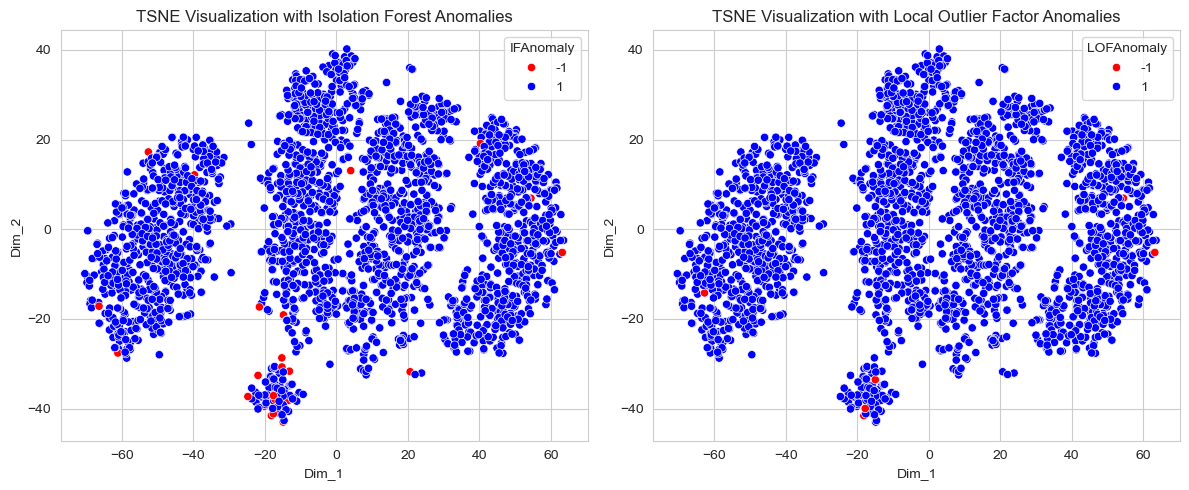

In [58]:
# Visualize the anomalies on TSNE plot
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
tsne_df['IFAnomaly'] = df['IFAnomaly']
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='IFAnomaly', palette=['red', 'blue'])
plt.title('TSNE Visualization with Isolation Forest Anomalies')

plt.subplot(1,2,2)
tsne_df['LOFAnomaly'] = df['LOFAnomaly']
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='LOFAnomaly', palette=['red', 'blue'])
plt.title('TSNE Visualization with Local Outlier Factor Anomalies')
plt.tight_layout()

Text(0.5, 1.0, 'Potential Fraudulent Transactions (Local Outlier Factor)')

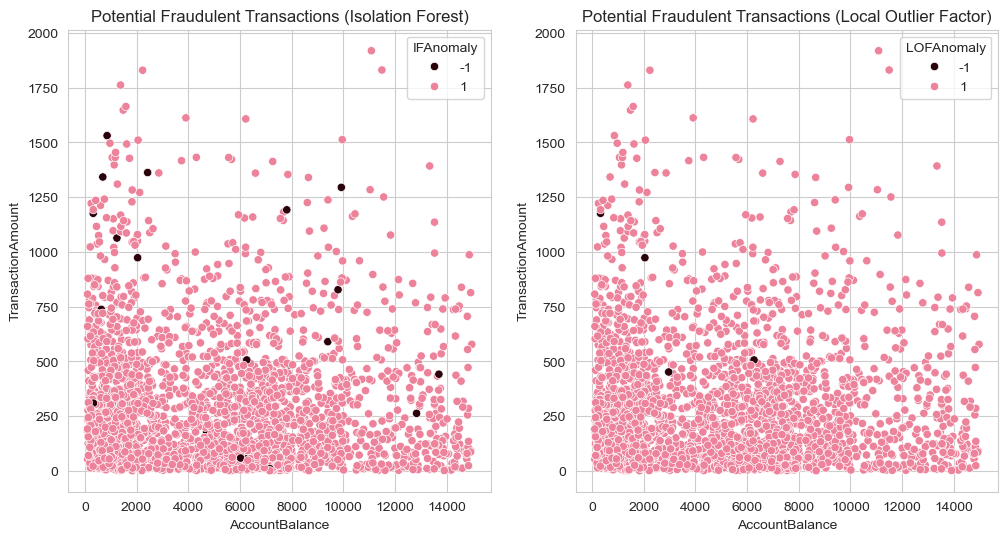

In [59]:
# Visualize potential fraud (AccountBalance vs. TransactionAmount)
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='AccountBalance', y='TransactionAmount', hue='IFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Potential Fraudulent Transactions (Isolation Forest)')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='AccountBalance', y='TransactionAmount', hue='LOFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Potential Fraudulent Transactions (Local Outlier Factor)')

Text(0.5, 1.0, 'Isolation Forest Anomalies Feature Correlations')

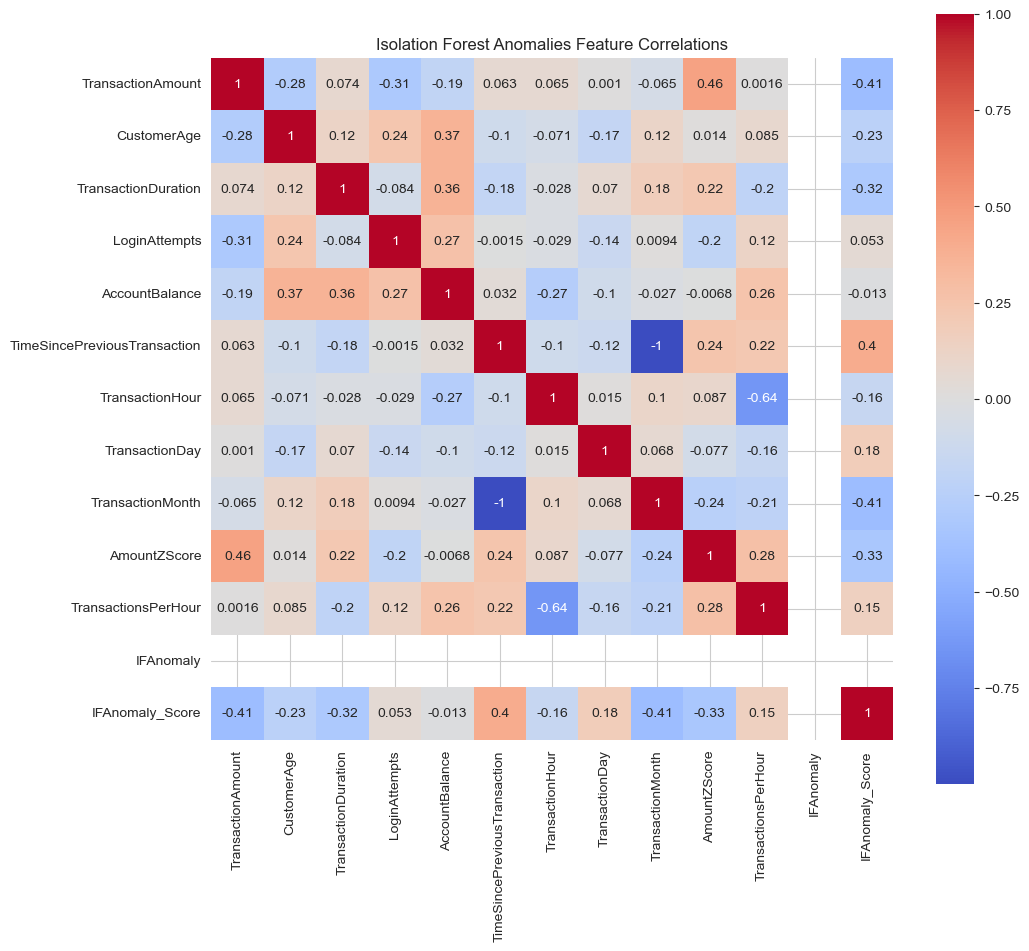

In [60]:
# Visualize the relationships between features in isolation forest anomalies
plt.figure(figsize=(11,10))
sns.heatmap(if_anomalies.select_dtypes(include='number').corr(), square=True, annot=True, cmap='coolwarm')
plt.title('Isolation Forest Anomalies Feature Correlations')

Text(0.5, 1.0, 'TransactionDuration vs. Account Balance (Isolation Forest)')

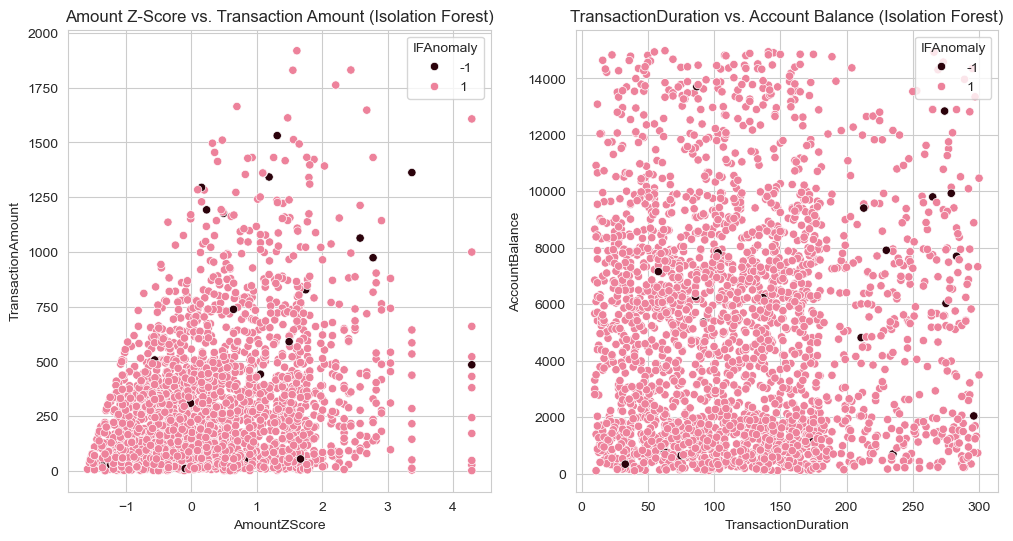

In [61]:
# Visualize the anomaly characteristics
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='AmountZScore', y='TransactionAmount', hue='IFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Amount Z-Score vs. Transaction Amount (Isolation Forest)')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='TransactionDuration', y='AccountBalance', hue='IFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('TransactionDuration vs. Account Balance (Isolation Forest)')

Text(0.5, 1.0, 'Local Outlier Factor Anomalies Feature Correlations')

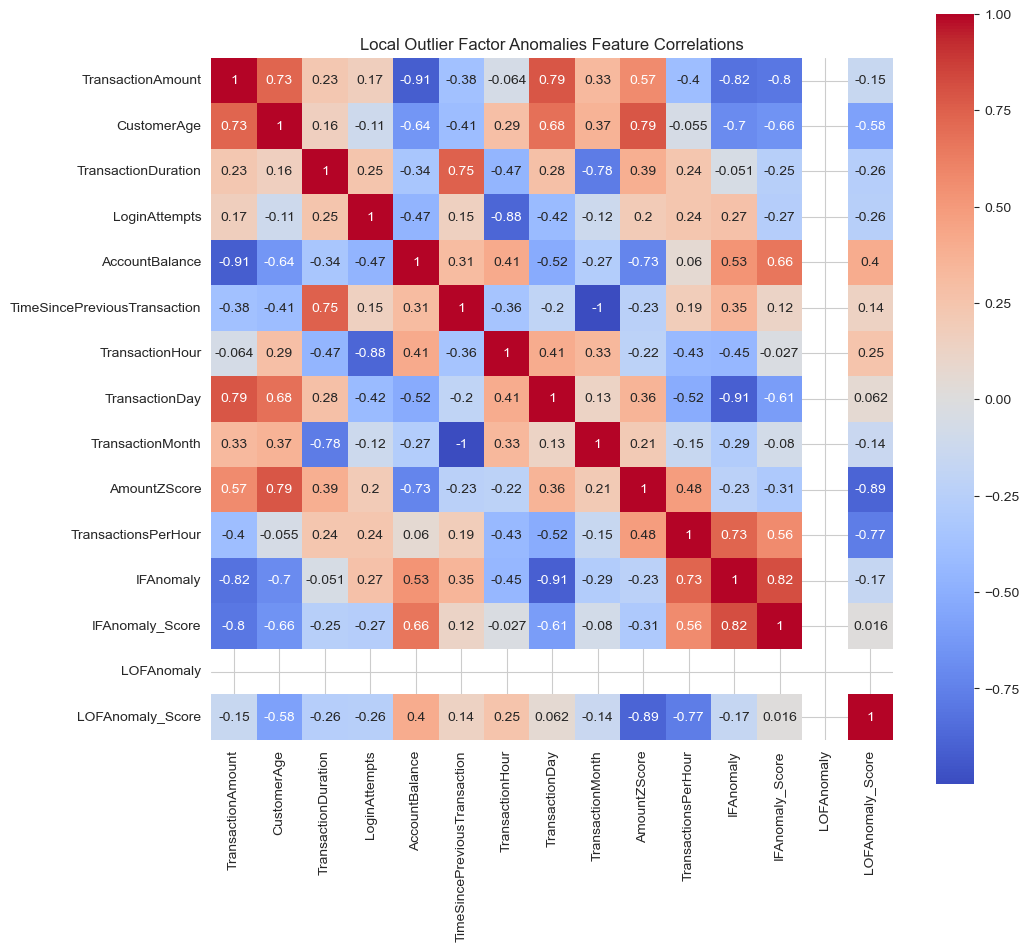

In [62]:
# Visualize the relationships between features in LOF anomalies
plt.figure(figsize=(11,10))
sns.heatmap(lof_anomalies.select_dtypes(include='number').corr(), square=True, annot=True, cmap='coolwarm')
plt.title('Local Outlier Factor Anomalies Feature Correlations')

Text(0.5, 1.0, 'Day of Transaction vs. Transaction Amount (Local Outlier Factor)')

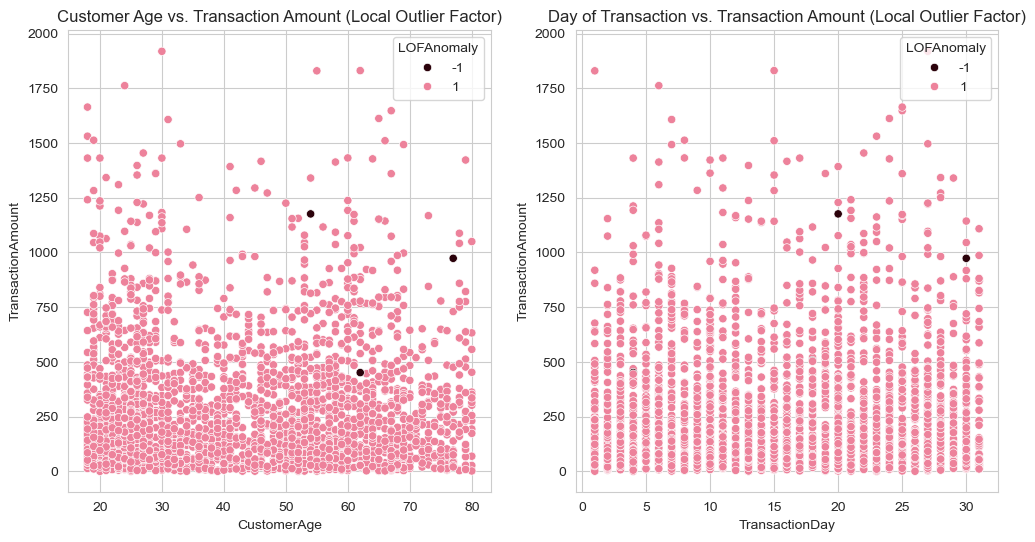

In [63]:
# Visualize the anomaly characteristics
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='CustomerAge', y='TransactionAmount', hue='LOFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Customer Age vs. Transaction Amount (Local Outlier Factor)')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='TransactionDay', y='TransactionAmount', hue='LOFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Day of Transaction vs. Transaction Amount (Local Outlier Factor)')

Text(0.5, 1.0, 'Transaction Amount vs. Transaction Day (Local Outlier Factor)')

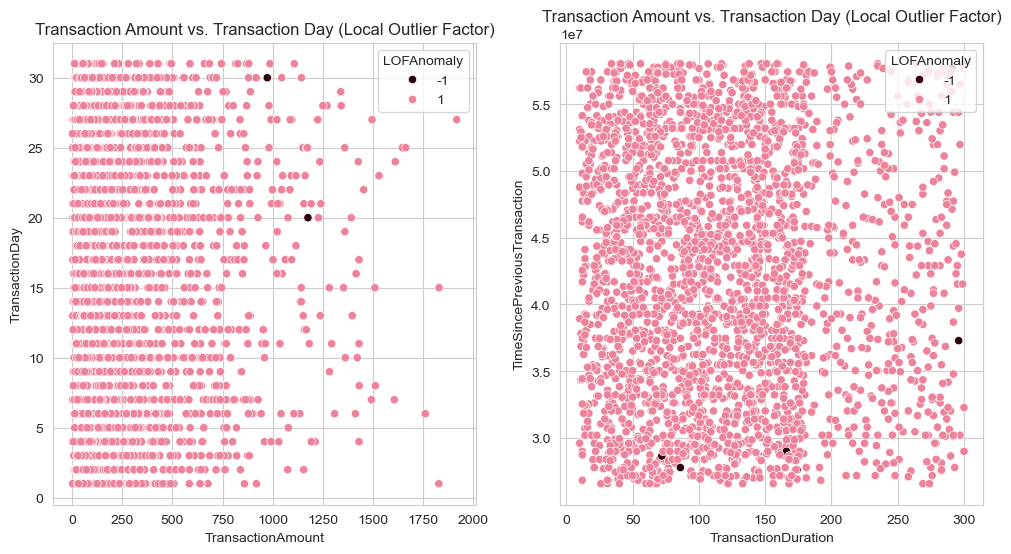

In [64]:
# Visualize the anomaly characteristics
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='TransactionAmount', y='TransactionDay', hue='LOFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Transaction Amount vs. Transaction Day (Local Outlier Factor)')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='TransactionDuration', y='TimeSincePreviousTransaction', hue='LOFAnomaly', palette=['#2b020b', '#ed829b'])
plt.title('Transaction Amount vs. Transaction Day (Local Outlier Factor)')